In [319]:
import pandas as pd
df = pd.read_csv('../data/month_1.csv')
df.head()

,YEAR,QUARTER,MONTH,FL_DATE,OP_UNIQUE_CARRIER,ORIGIN_AIRPORT_ID,ORIGIN,DEST_AIRPORT_ID,DEST,CRS_DEP_TIME,CRS_ARR_TIME,ARR_DELAY,CANCELLED,DIVERTED,CRS_ELAPSED_TIME,DISTANCE
0,2026,1,1,1/1/2026 12:00:00 AM,AA,10140,ABQ,11298,DFW,600,902,-31.0,0.0,0.0,122.0,569.0
1,2026,1,1,1/1/2026 12:00:00 AM,AA,10140,ABQ,11298,DFW,819,1121,-36.0,0.0,0.0,122.0,569.0
2,2026,1,1,1/1/2026 12:00:00 AM,AA,10140,ABQ,11298,DFW,1030,1330,2021.0,0.0,0.0,120.0,569.0
3,2026,1,1,1/1/2026 12:00:00 AM,AA,10140,ABQ,11298,DFW,1238,1538,-39.0,0.0,0.0,120.0,569.0
4,2026,1,1,1/1/2026 12:00:00 AM,AA,10140,ABQ,11298,DFW,1656,2000,86.0,0.0,0.0,124.0,569.0


In [320]:
df.info()
# print(df.isnull().sum()) # We dont have any null values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 544003 entries, 0 to 544002
Data columns (total 16 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   YEAR               544003 non-null  int64  
 1   QUARTER            544003 non-null  int64  
 2   MONTH              544003 non-null  int64  
 3   FL_DATE            544003 non-null  object 
 4   OP_UNIQUE_CARRIER  544003 non-null  object 
 5   ORIGIN_AIRPORT_ID  544003 non-null  int64  
 6   ORIGIN             544003 non-null  object 
 7   DEST_AIRPORT_ID    544003 non-null  int64  
 8   DEST               544003 non-null  object 
 9   CRS_DEP_TIME       544003 non-null  int64  
 10  CRS_ARR_TIME       544003 non-null  int64  
 11  ARR_DELAY          517222 non-null  float64
 12  CANCELLED          544003 non-null  float64
 13  DIVERTED           544003 non-null  float64
 14  CRS_ELAPSED_TIME   544003 non-null  float64
 15  DISTANCE           544003 non-null  float64
dtypes:

In [321]:
df["FL_DATE"] = pd.to_datetime(df["FL_DATE"])

df["CRS_DEP_TIME"] = (
    pd.to_numeric(df["CRS_DEP_TIME"], errors="coerce")
    .astype("Int64")
    .astype(str)
    .str.zfill(4)
)

df["CRS_DEP_TIME"] = pd.to_datetime(
    df["CRS_DEP_TIME"],
    format="%H%M",
    errors="coerce"
)


df["CRS_ARR_TIME"] = (
    pd.to_numeric(df["CRS_ARR_TIME"], errors="coerce")
    .astype("Int64")
    .astype(str)
    .str.zfill(4)
)

df["CRS_ARR_TIME"] = pd.to_datetime(
    df["CRS_ARR_TIME"],
    format="%H%M",
    errors="coerce"
)


df["CRS_ELAPSED_TIME"] = pd.to_numeric(
    df["CRS_ELAPSED_TIME"],
    errors="coerce"
)


df["year"] = df["FL_DATE"].dt.year

df["month"] = df["FL_DATE"].dt.month

df["quarter"] = df["FL_DATE"].dt.quarter

df["day"] = df["FL_DATE"].dt.day

df["day_of_week"] = df["FL_DATE"].dt.dayofweek

df["week_of_year"] = df["FL_DATE"].dt.isocalendar().week.astype(int)

df["is_weekend"] = (df["day_of_week"] >= 5).astype(int)


df["departure_hour"] = df["CRS_DEP_TIME"].dt.hour
df["departure_minute"] = df["CRS_DEP_TIME"].dt.minute


df["arrival_hour"] = df["CRS_ARR_TIME"].dt.hour
df["arrival_minute"] = df["CRS_ARR_TIME"].dt.minute



C:\Users\PC\AppData\Local\Temp\ipykernel_14768\3400476229.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["FL_DATE"] = pd.to_datetime(df["FL_DATE"])


In [322]:
# We check if the extracted year and month from FL_DATE match the original YEAR and MONTH columns. 
# If they don't match, it indicates a potential data inconsistency.

# year and month from FL_DATE
df["date_year"] = df["FL_DATE"].dt.year
df["date_month"] = df["FL_DATE"].dt.month

# Compare with original YEAR and MONTH columns
df["year_match"] = df["date_year"] == df["YEAR"]
df["month_match"] = df["date_month"] == df["MONTH"]

# Show mismatches
print("Year mismatches:", (~df["year_match"]).sum())
print("Month mismatches:", (~df["month_match"]).sum())

# Show rows where either year or month doesn't match
mismatch = df[
    (~df["year_match"]) |
    (~df["month_match"])
]

print(mismatch[
    [
        "FL_DATE",
        "YEAR",
        "date_year",
        "MONTH",
        "date_month"
    ]
].head(20))

Year mismatches: 0
Month mismatches: 0
Empty DataFrame
Columns: [FL_DATE, YEAR, date_year, MONTH, date_month]
Index: []


In [323]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 544003 entries, 0 to 544002
Data columns (total 31 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   YEAR               544003 non-null  int64         
 1   QUARTER            544003 non-null  int64         
 2   MONTH              544003 non-null  int64         
 3   FL_DATE            544003 non-null  datetime64[ns]
 4   OP_UNIQUE_CARRIER  544003 non-null  object        
 5   ORIGIN_AIRPORT_ID  544003 non-null  int64         
 6   ORIGIN             544003 non-null  object        
 7   DEST_AIRPORT_ID    544003 non-null  int64         
 8   DEST               544003 non-null  object        
 9   CRS_DEP_TIME       544003 non-null  datetime64[ns]
 10  CRS_ARR_TIME       544003 non-null  datetime64[ns]
 11  ARR_DELAY          517222 non-null  float64       
 12  CANCELLED          544003 non-null  float64       
 13  DIVERTED           544003 non-null  float64 

In [324]:
print(df['OP_UNIQUE_CARRIER'].unique().size)
print(df['ORIGIN'].unique().size)
print(df['ORIGIN'].value_counts())
df["ORIGIN"].value_counts().describe()

13
341
ORIGIN
ORD    25131
ATL    24595
DEN    24484
DFW    24229
PHX    16564
       ...  
PPG       14
ADK        9
CKB        9
EWN        5
BQK        4
Name: count, Length: 341, dtype: int64


count      341.000000
mean      1595.316716
std       3719.575232
min          4.000000
25%         62.000000
50%        266.000000
75%       1037.000000
max      25131.000000
Name: count, dtype: float64

In [325]:
print("Unique origins:", df["ORIGIN"].nunique())
print("Unique destinations:", df["DEST_AIRPORT_ID"].nunique())

Unique origins: 341
Unique destinations: 342


In [326]:
print("Shape:", df.shape)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicates:")
print(df.duplicated().sum())

print("\nData types:")
print(df.dtypes)

print("\nUnique values:")
print(df.nunique().sort_values())

Shape: (544003, 31)

Missing values:
YEAR                     0
QUARTER                  0
MONTH                    0
FL_DATE                  0
OP_UNIQUE_CARRIER        0
ORIGIN_AIRPORT_ID        0
ORIGIN                   0
DEST_AIRPORT_ID          0
DEST                     0
CRS_DEP_TIME             0
CRS_ARR_TIME             0
ARR_DELAY            26781
CANCELLED                0
DIVERTED                 0
CRS_ELAPSED_TIME         0
DISTANCE                 0
year                     0
month                    0
quarter                  0
day                      0
day_of_week              0
week_of_year             0
is_weekend               0
departure_hour           0
departure_minute         0
arrival_hour             0
arrival_minute           0
date_year                0
date_month               0
year_match               0
month_match              0
dtype: int64

Duplicates:
0

Data types:
YEAR                          int64
QUARTER                       int64
MONTH        

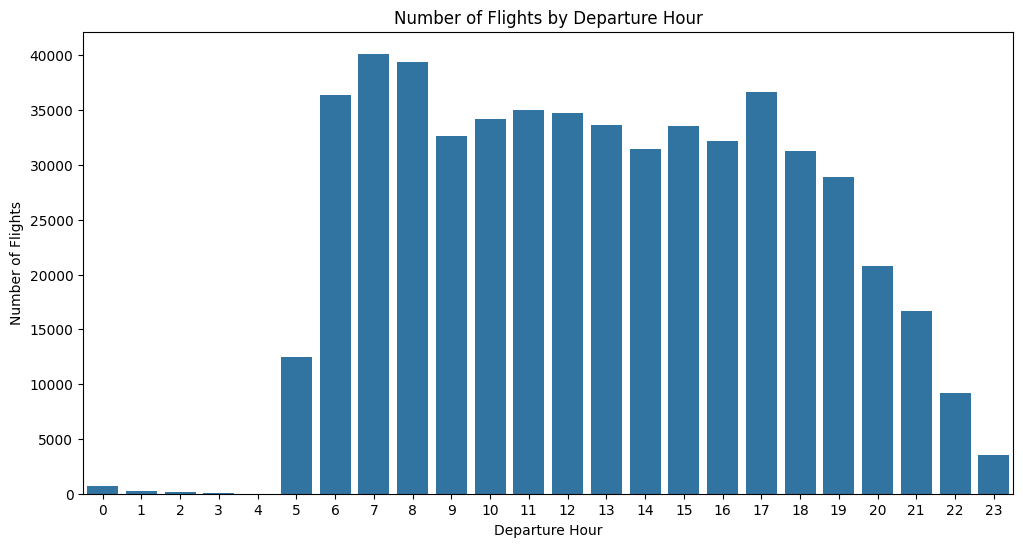

In [327]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))

sns.countplot(
    data=df,
    x="departure_hour"
)

plt.title("Number of Flights by Departure Hour")
plt.xlabel("Departure Hour")
plt.ylabel("Number of Flights")
plt.xticks(range(24))
plt.show()

In [328]:
df_co = df[df['CANCELLED'] == 0]
df_co = df_co[df_co['DIVERTED'] == 0]
print("Missing ArrDelay:", df_co["ARR_DELAY"].isna().sum())
print("Rows:", len(df_co))
df = df[
    (df["CANCELLED"] == 0) &
    (df["DIVERTED"] == 0)
].copy()

Missing ArrDelay: 0
Rows: 517222


In [329]:
print(df.shape)
print(df.columns)

(517222, 31)
Index(['YEAR', 'QUARTER', 'MONTH', 'FL_DATE', 'OP_UNIQUE_CARRIER',
       'ORIGIN_AIRPORT_ID', 'ORIGIN', 'DEST_AIRPORT_ID', 'DEST',
       'CRS_DEP_TIME', 'CRS_ARR_TIME', 'ARR_DELAY', 'CANCELLED', 'DIVERTED',
       'CRS_ELAPSED_TIME', 'DISTANCE', 'year', 'month', 'quarter', 'day',
       'day_of_week', 'week_of_year', 'is_weekend', 'departure_hour',
       'departure_minute', 'arrival_hour', 'arrival_minute', 'date_year',
       'date_month', 'year_match', 'month_match'],
      dtype='object')


In [330]:
print(df["ARR_DELAY"].describe())

count    517222.00000
mean          6.41036
std          63.39614
min         -85.00000
25%         -18.00000
50%          -7.00000
75%           9.00000
max        3339.00000
Name: ARR_DELAY, dtype: float64


In [331]:
print("Minimum:", df["ARR_DELAY"].min())
print("Maximum:", df["ARR_DELAY"].max())
print("Mean:", df["ARR_DELAY"].mean())
print("Median:", df["ARR_DELAY"].median())

Minimum: -85.0
Maximum: 3339.0
Mean: 6.410359574805403
Median: -7.0


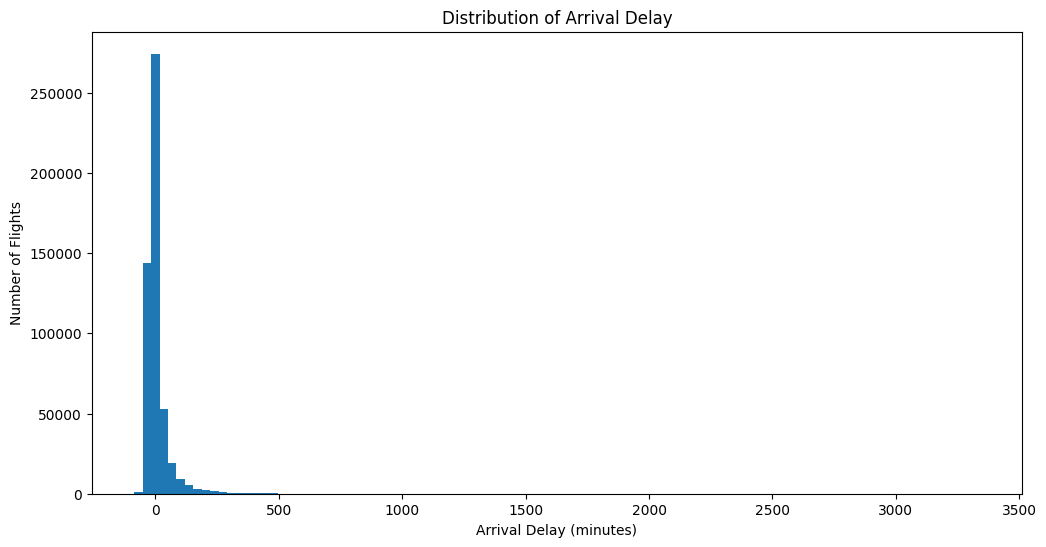

In [332]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.hist(df["ARR_DELAY"], bins=100)

plt.title("Distribution of Arrival Delay")
plt.xlabel("Arrival Delay (minutes)")
plt.ylabel("Number of Flights")

plt.show()


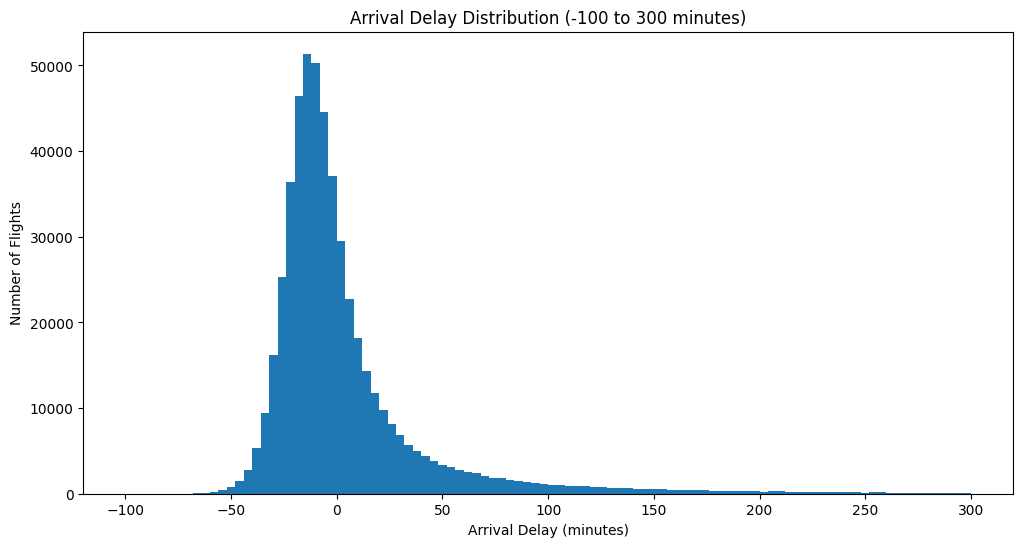

In [333]:
plt.figure(figsize=(12, 6))

plt.hist(
    df["ARR_DELAY"],
    bins=100,
    range=(-100, 300)
)

plt.title("Arrival Delay Distribution (-100 to 300 minutes)")
plt.xlabel("Arrival Delay (minutes)")
plt.ylabel("Number of Flights")

plt.show()

                        mean  median   count
OP_UNIQUE_CARRIER                           
B6                 16.087111    -2.0   16875
OH                 14.029686    -9.0   17247
AA                 13.812733    -6.0   69740
F9                 13.565567    -6.0   14817
OO                 13.165552    -8.0   63708
NK                 10.401919    -6.0   11047
G4                 10.168770    -9.0    8716
MQ                  4.984864    -8.0   22926
AS                  4.339587    -4.0   25799
DL                  3.934368    -8.0   75939
YX                  2.511877   -11.0   27112
UA                  2.016132    -8.0   62176
WN                 -1.215615    -8.0  101120


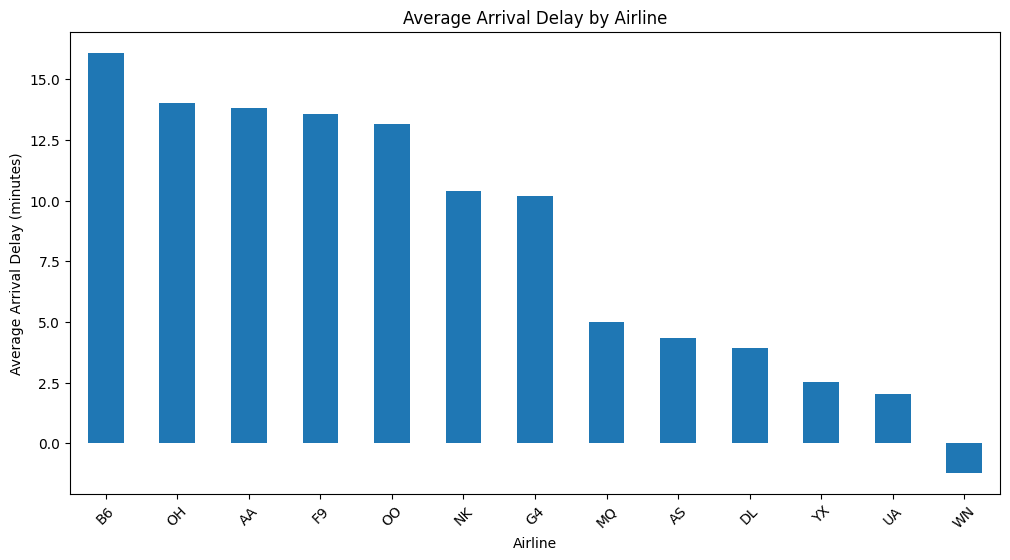

In [334]:
airline_delay = (
    df.groupby("OP_UNIQUE_CARRIER")["ARR_DELAY"]
      .agg(["mean", "median", "count"])
      .sort_values("mean", ascending=False)
)

print(airline_delay)


plt.figure(figsize=(12, 6))

airline_delay["mean"].plot(kind="bar")

plt.title("Average Arrival Delay by Airline")
plt.xlabel("Airline")
plt.ylabel("Average Arrival Delay (minutes)")
plt.xticks(rotation=45)

plt.show()

                     mean  median  count
departure_hour                          
0               -1.940928   -11.0    711
1                4.987288   -10.0    236
2                7.099237    -7.0    131
3                8.333333    -6.5     36
4               29.500000    28.5      4
5               -0.680991   -12.0  11868
6               -0.041010   -12.0  34284
7                0.869078   -10.0  38160
8                2.077364    -9.0  37369
9                3.091966    -8.0  31229
10               4.484868    -8.0  32382
11               5.191554    -7.0  33437
12               6.380800    -8.0  33125
13               7.443071    -7.0  32198
14               8.534427    -7.0  30049
15               9.796090    -6.0  32024
16              10.597979    -5.0  30685
17              10.221244    -5.0  34758
18               9.925707    -5.0  29774
19              11.927813    -5.0  27304
20               9.615903    -5.0  19883
21              12.051793    -6.0  15562
22              

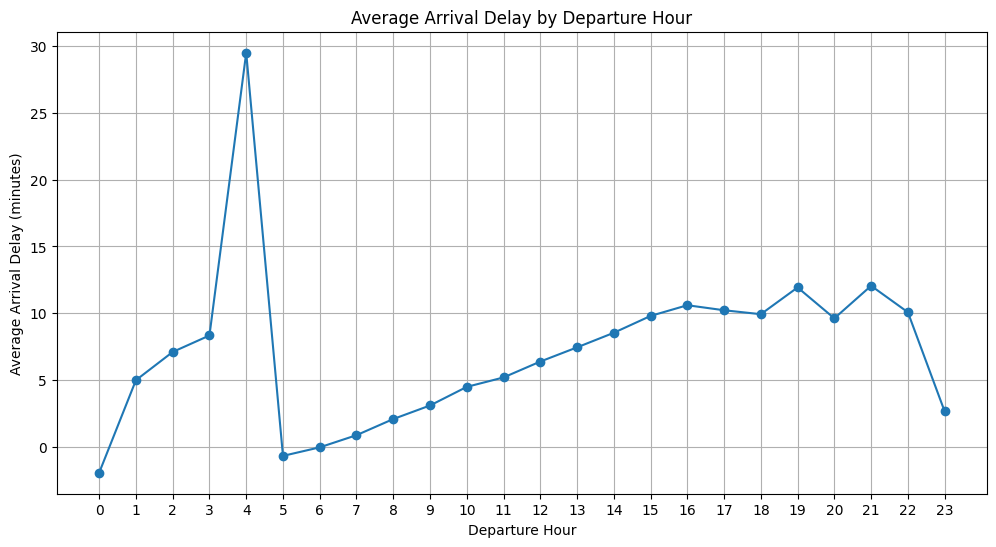

In [335]:
hour_delay = (
    df.groupby("departure_hour")["ARR_DELAY"]
      .agg(["mean", "median", "count"])
)

print(hour_delay)
plt.figure(figsize=(12, 6))

hour_delay["mean"].plot(
    kind="line",
    marker="o"
)

plt.title("Average Arrival Delay by Departure Hour")
plt.xlabel("Departure Hour")
plt.ylabel("Average Arrival Delay (minutes)")
plt.xticks(range(24))
plt.grid()

plt.show()

In [336]:
hour_delay = (
    df.groupby("departure_hour")["ARR_DELAY"]
      .agg(["mean", "median", "count"])
)

print(hour_delay)
# 4               29.500000    28.5 ,4   # the count is 4 

                     mean  median  count
departure_hour                          
0               -1.940928   -11.0    711
1                4.987288   -10.0    236
2                7.099237    -7.0    131
3                8.333333    -6.5     36
4               29.500000    28.5      4
5               -0.680991   -12.0  11868
6               -0.041010   -12.0  34284
7                0.869078   -10.0  38160
8                2.077364    -9.0  37369
9                3.091966    -8.0  31229
10               4.484868    -8.0  32382
11               5.191554    -7.0  33437
12               6.380800    -8.0  33125
13               7.443071    -7.0  32198
14               8.534427    -7.0  30049
15               9.796090    -6.0  32024
16              10.597979    -5.0  30685
17              10.221244    -5.0  34758
18               9.925707    -5.0  29774
19              11.927813    -5.0  27304
20               9.615903    -5.0  19883
21              12.051793    -6.0  15562
22              

In [337]:
day_delay = (
    df.groupby("day_of_week")["ARR_DELAY"]
      .agg(["mean", "median", "count"])
)

print(day_delay)

                  mean  median  count
day_of_week                          
0            12.814769    -6.0  68876
1             1.365028   -11.0  62650
2             0.536252   -10.0  64382
3             3.789284    -8.0  89903
4             6.119213    -7.0  91718
5             6.926004    -6.0  74707
6            13.750254    -4.0  64986


In [338]:
origin_delay = (
    df.groupby("ORIGIN")["ARR_DELAY"]
      .agg(["mean", "median", "count"])
)

origin_delay_filtered = (
    origin_delay[origin_delay["count"] >= 500]
    .sort_values("mean", ascending=False)
)

print(origin_delay_filtered.head(20))

             mean  median  count
ORIGIN                          
SBN     40.709150     5.0    612
STT     32.266038    -7.0    530
GRR     26.251114     3.0   1346
ATW     24.100840    -5.0    595
ASE     21.577046    -9.0    941
DTW     21.357753     0.0   9132
FAR     20.335727    -6.0    557
EGE     19.751524    -7.0    656
EYW     18.893285    -5.0    834
SYR     18.429608     0.0    689
ORD     18.175985    -2.0  24127
ROC     17.448718    -3.0    702
HPN     17.324228    -3.0    842
MSN     16.457856    -9.0    961
SJU     15.918892    -4.0   3033
BUF     14.730222    -1.5   1264
CID     14.195122    -7.0    656
DAY     12.894646   -14.0    579
TYS     12.789474   -11.5    836
DFW     12.658697    -4.0  21790


In [339]:
dest_delay = (
    df.groupby("DEST")["ARR_DELAY"]
      .agg(["mean", "median", "count"])
      .sort_values("mean", ascending=False)
)

print(dest_delay[dest_delay["count"] >= 500].head(20))

           mean  median  count
DEST                          
SBN   33.834967     0.0    612
DAY   22.263525    -4.0    573
MSN   19.700617    -1.0    972
FAR   18.096257    -3.0    561
SJU   17.219729     1.0   3031
DTW   16.329096    -5.0   9125
SFB   16.295148    -2.5    742
GRR   16.258016    -2.0   1341
ORD   16.254798    -4.0  24019
ATW   16.254209    -4.0    594
TYS   15.933413    -5.0    841
DCA   15.834921    -5.0  10710
SYR   14.663781    -3.0    693
BUF   13.992101    -4.0   1266
HPN   13.736842    -5.0    836
PBI   13.086971    -1.5   2932
EGE   12.862330    -1.0    661
PIE   12.742998    -9.0    607
FLL   12.692618    -2.0   8169
ASE   12.340885    -9.0    927


In [340]:
dest_delay = (
    df.groupby("DEST")["ARR_DELAY"]
      .agg(["mean", "median", "count"])
)

dest_delay = (
    dest_delay[dest_delay["count"] >= 500]
    .sort_values("mean", ascending=False)
)

print(dest_delay.head(20))

           mean  median  count
DEST                          
SBN   33.834967     0.0    612
DAY   22.263525    -4.0    573
MSN   19.700617    -1.0    972
FAR   18.096257    -3.0    561
SJU   17.219729     1.0   3031
DTW   16.329096    -5.0   9125
SFB   16.295148    -2.5    742
GRR   16.258016    -2.0   1341
ORD   16.254798    -4.0  24019
ATW   16.254209    -4.0    594
TYS   15.933413    -5.0    841
DCA   15.834921    -5.0  10710
SYR   14.663781    -3.0    693
BUF   13.992101    -4.0   1266
HPN   13.736842    -5.0    836
PBI   13.086971    -1.5   2932
EGE   12.862330    -1.0    661
PIE   12.742998    -9.0    607
FLL   12.692618    -2.0   8169
ASE   12.340885    -9.0    927


In [341]:
distance_delay_q = (
    df.groupby(
        pd.qcut(df["DISTANCE"], q=10, duplicates="drop"),
        observed=True
    )["ARR_DELAY"]
    .agg(["mean", "median", "count"])
)

print(distance_delay_q)

                      mean  median  count
DISTANCE                                 
(30.999, 231.0]   9.204823    -6.0  51874
(231.0, 345.0]    6.854336    -9.0  51653
(345.0, 455.0]    4.892513    -9.0  51997
(455.0, 588.0]    6.609699    -8.0  52193
(588.0, 707.0]    5.591466    -8.0  50926
(707.0, 862.0]    4.637086    -8.0  52635
(862.0, 1009.0]   5.996634    -7.0  50807
(1009.0, 1197.0]  8.954837    -6.0  51945
(1197.0, 1671.0]  5.902860    -7.0  51925
(1671.0, 4983.0]  5.451948    -7.0  51267


In [342]:
duration_delay = (
    df.groupby(
        pd.qcut(df["CRS_ELAPSED_TIME"], q=10, duplicates="drop"),
        observed=True
    )["ARR_DELAY"]
    .agg(["mean", "median", "count"])
)

print(duration_delay)

                      mean  median  count
CRS_ELAPSED_TIME                         
(24.999, 77.0]    7.235069    -6.0  53244
(77.0, 90.0]      5.925831    -8.0  51167
(90.0, 105.0]     6.563553    -8.0  53239
(105.0, 120.0]    6.777231    -8.0  50779
(120.0, 137.0]    6.314649    -8.0  51934
(137.0, 155.0]    5.506934    -8.0  51482
(155.0, 174.0]    6.667296    -7.0  50829
(174.0, 198.0]    7.347921    -7.0  51138
(198.0, 255.0]    6.473195    -7.0  52173
(255.0, 1202.0]   5.264574    -7.0  51237


In [343]:
negative_duration = df[df["CRS_ELAPSED_TIME"] < 0]

print("Negative durations:", len(negative_duration))
print("Percentage:",
      len(negative_duration) / len(df) * 100)

print(
    negative_duration[
        ["FL_DATE", "ORIGIN", "DEST", "CRS_ELAPSED_TIME"]
    ].head(20)
)

df = df[df["CRS_ELAPSED_TIME"] >= 0].copy()

print("Rows:", len(df))
print("Negative durations:", (df["CRS_ELAPSED_TIME"] < 0).sum())

Negative durations: 0
Percentage: 0.0
Empty DataFrame
Columns: [FL_DATE, ORIGIN, DEST, CRS_ELAPSED_TIME]
Index: []
Rows: 517222
Negative durations: 0


In [344]:
print("Missing ARR_DELAY:", df["ARR_DELAY"].isna().sum())
print("Target min:", df["ARR_DELAY"].min())
print("Target max:", df["ARR_DELAY"].max())



print(
    df[df["ARR_DELAY"].isna()][
        [
            "FL_DATE",
            "OP_UNIQUE_CARRIER",
            "ORIGIN",
            "DEST",
            "CANCELLED",
            "DIVERTED"
        ]
    ].head(20)
)

Missing ARR_DELAY: 0
Target min: -85.0
Target max: 3339.0
Empty DataFrame
Columns: [FL_DATE, OP_UNIQUE_CARRIER, ORIGIN, DEST, CANCELLED, DIVERTED]
Index: []


In [349]:
print(df.shape)
print(df.info())

(517222, 21)
<class 'pandas.core.frame.DataFrame'>
Index: 517222 entries, 0 to 544002
Data columns (total 21 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   FL_DATE            517222 non-null  datetime64[ns]
 1   OP_UNIQUE_CARRIER  517222 non-null  object        
 2   ORIGIN_AIRPORT_ID  517222 non-null  int64         
 3   ORIGIN             517222 non-null  object        
 4   DEST_AIRPORT_ID    517222 non-null  int64         
 5   DEST               517222 non-null  object        
 6   ARR_DELAY          517222 non-null  float64       
 7   CRS_ELAPSED_TIME   517222 non-null  float64       
 8   DISTANCE           517222 non-null  float64       
 9   year               517222 non-null  int32         
 10  month              517222 non-null  int32         
 11  quarter            517222 non-null  int32         
 12  day                517222 non-null  int32         
 13  day_of_week        517222 non-null  

In [346]:
df.drop(
    columns=[
        "YEAR",
        "QUARTER",
        "MONTH",
        "CANCELLED",
        "DIVERTED",
        "date_year",
        "date_month",
        "year_match",
        "month_match",
        "CRS_DEP_TIME",
        "CRS_ARR_TIME",
        "CANCELLED",
        "DIVERTED"
    ],
    inplace=True
)

In [347]:
print("Number of columns:", df.shape[1])
print(df.columns.tolist())

Number of columns: 20
['FL_DATE', 'OP_UNIQUE_CARRIER', 'ORIGIN_AIRPORT_ID', 'ORIGIN', 'DEST_AIRPORT_ID', 'DEST', 'ARR_DELAY', 'CRS_ELAPSED_TIME', 'DISTANCE', 'year', 'month', 'quarter', 'day', 'day_of_week', 'week_of_year', 'is_weekend', 'departure_hour', 'departure_minute', 'arrival_hour', 'arrival_minute']


In [348]:
df["ROUTE"] = df["ORIGIN"] + "_" + df["DEST"]
print(df["ROUTE"].nunique())

5805


Train: (413777, 21)
Test: (103445, 21)
Train period:
2026-01-01 00:00:00 → 2026-01-24 00:00:00
Test period:
2026-01-24 00:00:00 → 2026-01-31 00:00:00


In [ ]:
plt.figure(figsize=(12, 6))

plt.hist(
    df["ARR_DELAY"],
    bins=100,   
    alpha=0.7,
    color="skyblue",
    range=(-100, 300)
)

plt.title("Arrival Delay Distribution (-100 to 300 minutes)")
plt.xlabel("Arrival Delay (minutes)")
plt.ylabel("Number of Flights")

plt.show()